In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

df = pd.read_csv("/content/sample_data/industrialcombenergy-2014.csv")
df.head()

,FACILITY_ID,FACILITY_NAME,FUEL_TYPE,OTHER_OR_BLEND_FUEL_TYPE,REPORTING_YEAR,UNIT_NAME,UNIT_TYPE,PRIMARY_NAICS_CODE,PRIMARY_NAICS_TITLE,COGENERATION_UNIT_EMISS_IND,MMBtu_TOTAL,GWht_TOTAL,GROUPING
0,1003826,ATLANTIC WASTE DISPOSAL INC - SUSSEX COUNTY LAND,Propane Gas,Other (gas),2014,PROPHTR003,CH (Comfort heater),562212,Solid Waste Landfill,N,1095.021152,0.320921,Administrative and Support and Waste Managemen...
1,1003826,ATLANTIC WASTE DISPOSAL INC - SUSSEX COUNTY LAND,Propane Gas,Other (gas),2014,PROPHTR001,CH (Comfort heater),562212,Solid Waste Landfill,N,1488.773186,0.436319,Administrative and Support and Waste Managemen...
2,1003826,ATLANTIC WASTE DISPOSAL INC - SUSSEX COUNTY LAND,Propane Gas,Other (gas),2014,PROPHTR002,CH (Comfort heater),562212,Solid Waste Landfill,N,1488.773186,0.436319,Administrative and Support and Waste Managemen...
3,1003826,ATLANTIC WASTE DISPOSAL INC - SUSSEX COUNTY LAND,Propane Gas,Other (gas),2014,WTRHTR001,"HWH (Heater, hot water)",562212,Solid Waste Landfill,N,2803.449398,0.821615,Administrative and Support and Waste Managemen...
4,1005928,LARIMER COUNTY LANDFILL,Liquefied petroleum gases (LPG),Other (gas),2014,GP-1,OCS (Other combustion source),562212,Solid Waste Landfill,N,847.512559,0.248383,Administrative and Support and Waste Managemen...


# Do we have missing data? And where are they concentrated?(heatmap of nulls)

In [ ]:
# A quick numeric summary of missing values
missing_counts = df.isnull().sum().sort_values(ascending=False)
print(missing_counts)

FACILITY_ID                    0
FACILITY_NAME                  0
FUEL_TYPE                      0
OTHER_OR_BLEND_FUEL_TYPE       0
REPORTING_YEAR                 0
UNIT_NAME                      0
UNIT_TYPE                      0
PRIMARY_NAICS_CODE             0
PRIMARY_NAICS_TITLE            0
COGENERATION_UNIT_EMISS_IND    0
MMBtu_TOTAL                    0
GWht_TOTAL                     0
GROUPING                       0
dtype: int64


# Dominant fuel types (barplot)

/tmp/ipython-input-2047356083.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuel_counts.values, y=fuel_counts.index, palette="viridis")


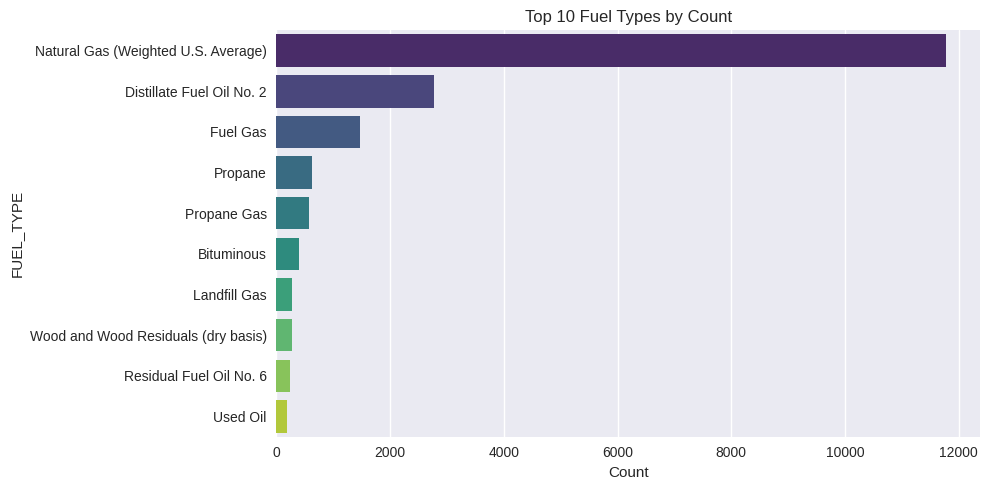

,count
FUEL_TYPE,
Natural Gas (Weighted U.S. Average),11787
Distillate Fuel Oil No. 2,2767
Fuel Gas,1464
Propane,624
Propane Gas,567
Bituminous,399
Landfill Gas,282
Wood and Wood Residuals (dry basis),267
Residual Fuel Oil No. 6,247


In [ ]:
fuel_counts = df["FUEL_TYPE"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=fuel_counts.values, y=fuel_counts.index, palette="viridis")
plt.title("Top 10 Fuel Types by Count")
plt.xlabel("Count")
plt.ylabel("FUEL_TYPE")
plt.tight_layout()
plt.show()

display(fuel_counts)

#What is the most important segment for the industry data?

/tmp/ipython-input-2472298348.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_counts.values, y=group_counts.index, palette="magma")


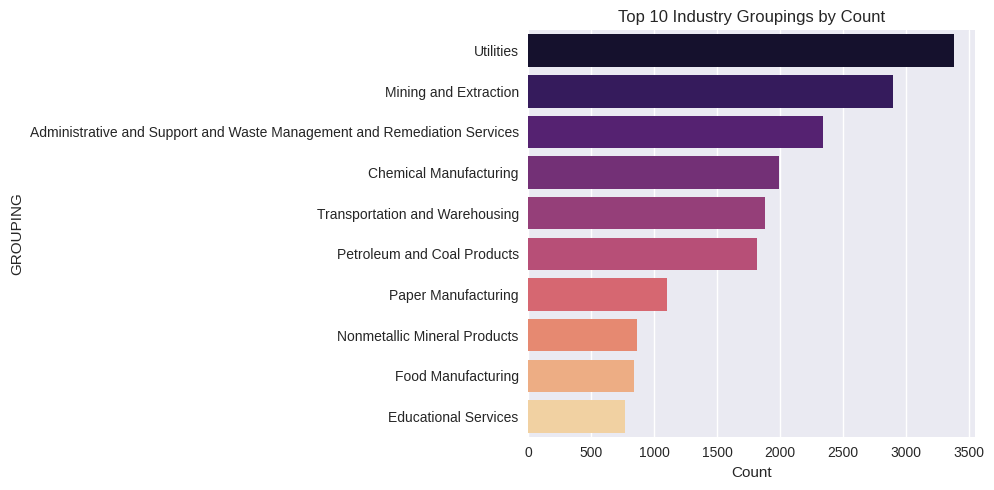

,count
GROUPING,
Utilities,3381
Mining and Extraction,2894
Administrative and Support and Waste Management and Remediation Services,2342
Chemical Manufacturing,1987
Transportation and Warehousing,1879
Petroleum and Coal Products,1813
Paper Manufacturing,1102
Nonmetallic Mineral Products,860
Food Manufacturing,842


In [ ]:
group_counts = df["GROUPING"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=group_counts.values, y=group_counts.index, palette="magma")
plt.title("Top 10 Industry Groupings by Count")
plt.xlabel("Count")
plt.ylabel("GROUPING")
plt.tight_layout()
plt.show()

display(group_counts)

##What does the distribution of energy values ​​(MMBtu_TOTAL and GWht_TOTAL) look like? Are there any clear outliers?

/tmp/ipython-input-2729761144.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=naics_counts.values, y=naics_counts.index, palette="Blues_r")


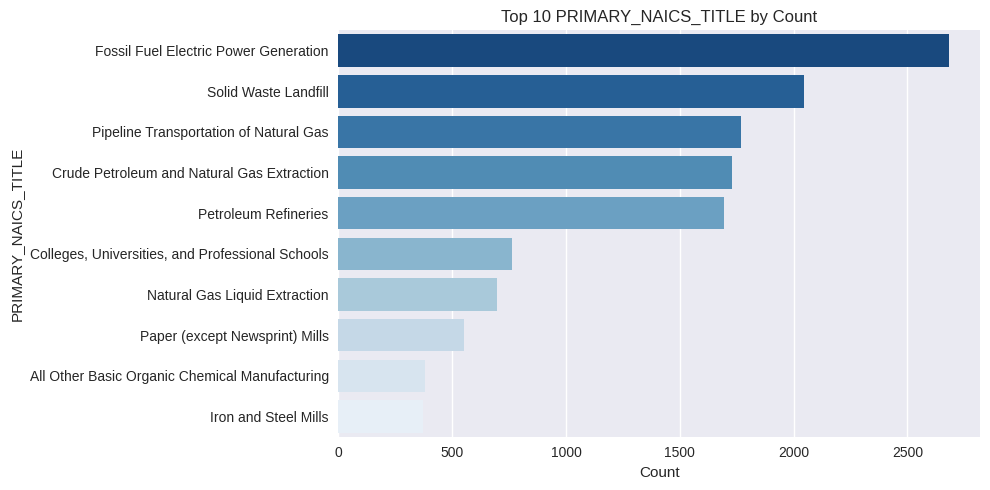

,count
PRIMARY_NAICS_TITLE,
Fossil Fuel Electric Power Generation,2685
Solid Waste Landfill,2048
Pipeline Transportation of Natural Gas,1770
Crude Petroleum and Natural Gas Extraction,1728
Petroleum Refineries,1696
"Colleges, Universities, and Professional Schools",765
Natural Gas Liquid Extraction,695
Paper (except Newsprint) Mills,552
All Other Basic Organic Chemical Manufacturing,381


In [ ]:
naics_counts = df["PRIMARY_NAICS_TITLE"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=naics_counts.values, y=naics_counts.index, palette="Blues_r")
plt.title("Top 10 PRIMARY_NAICS_TITLE by Count")
plt.xlabel("Count")
plt.ylabel("PRIMARY_NAICS_TITLE")
plt.tight_layout()
plt.show()

display(naics_counts)

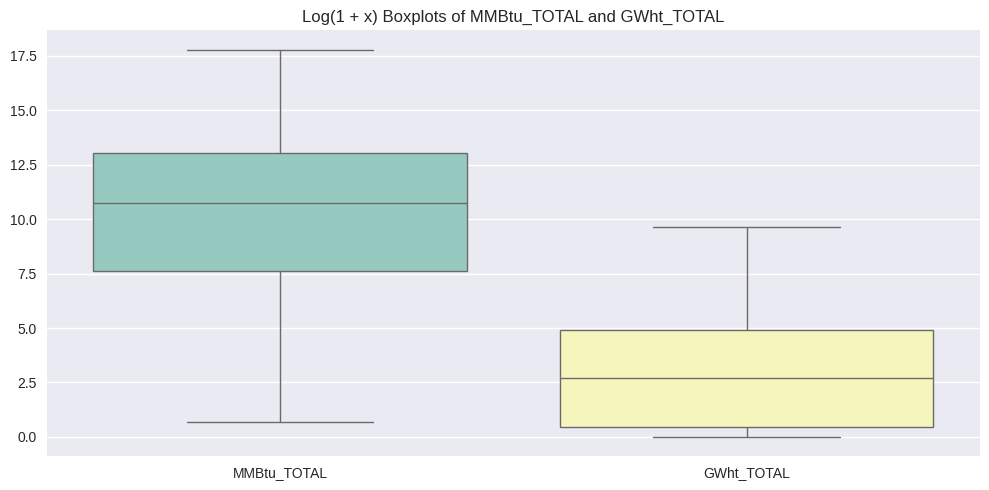

In [30]:
numeric_cols = ["MMBtu_TOTAL", "GWht_TOTAL"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df_log = df[numeric_cols].copy()
for col in numeric_cols:
    df_log[col] = np.log1p(df_log[col])

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_log, palette="Set3")
plt.title("Log(1 + x) Boxplots of MMBtu_TOTAL and GWht_TOTAL")
plt.tight_layout()
plt.show()

#How are categories (such as fuel types) distributed across industrial sectors?

/tmp/ipython-input-2211225988.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


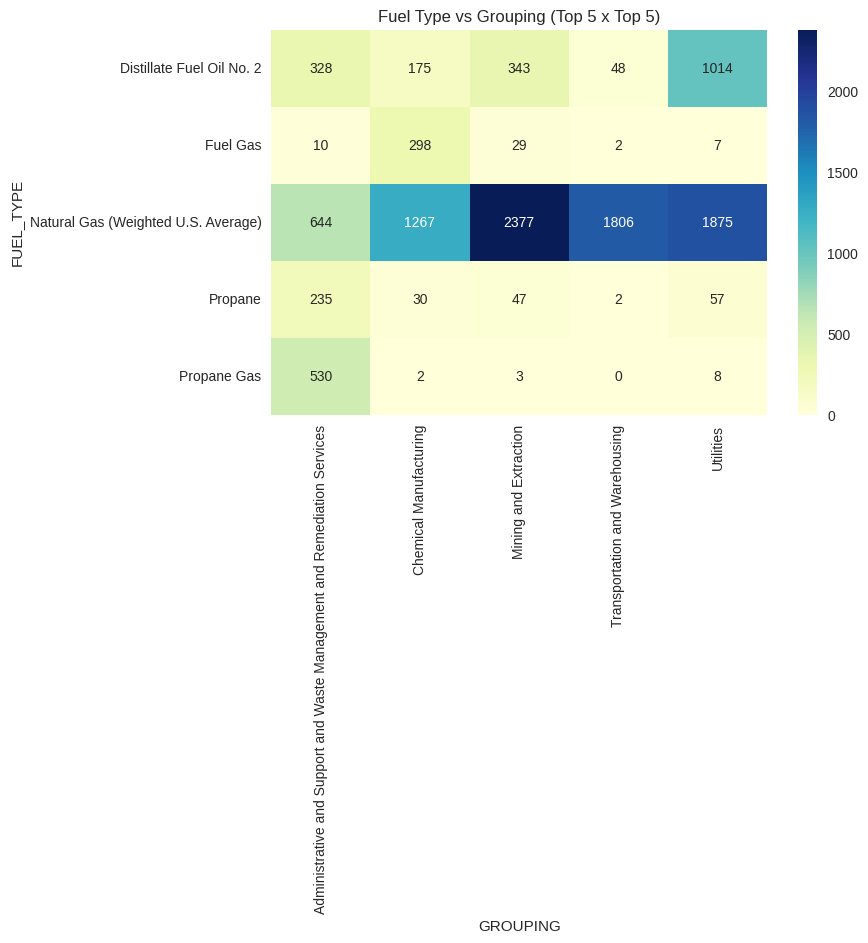

GROUPING,Administrative and Support and Waste Management and Remediation Services,Chemical Manufacturing,Mining and Extraction,Transportation and Warehousing,Utilities
FUEL_TYPE,,,,,
Distillate Fuel Oil No. 2,328,175,343,48,1014
Fuel Gas,10,298,29,2,7
Natural Gas (Weighted U.S. Average),644,1267,2377,1806,1875
Propane,235,30,47,2,57
Propane Gas,530,2,3,0,8


In [ ]:
# Use a crosstab to see counts fuel vs grouping (top categories only)
top_fuels = df["FUEL_TYPE"].value_counts().head(5).index
top_groups = df["GROUPING"].value_counts().head(5).index

df_cat = df[df["FUEL_TYPE"].isin(top_fuels) & df["GROUPING"].isin(top_groups)]

ct = pd.crosstab(df_cat["FUEL_TYPE"], df_cat["GROUPING"])

plt.figure(figsize=(8, 5))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Fuel Type vs Grouping (Top 5 x Top 5)")
plt.tight_layout()
plt.show()

display(ct)

#How strong is the correlation between MMBtu_TOTAL and GWht_TOTAL?

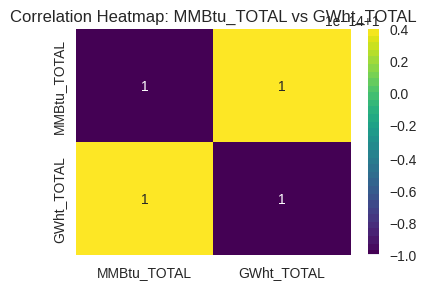

,MMBtu_TOTAL,GWht_TOTAL
MMBtu_TOTAL,1.0,1.0
GWht_TOTAL,1.0,1.0


In [ ]:
corr = df[["MMBtu_TOTAL", "GWht_TOTAL"]].corr()

plt.figure(figsize=(4, 3))
sns.heatmap(corr, annot=True, cmap="viridis")
plt.title("Correlation Heatmap: MMBtu_TOTAL vs GWht_TOTAL")
plt.tight_layout()
plt.show()

display(corr)

#Does the relationship between MMBtu_TOTAL and GWht_TOTAL actually appear to be linear?

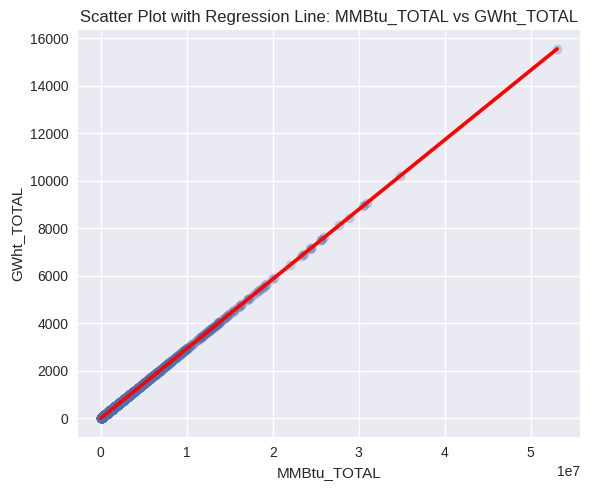

In [ ]:
plt.figure(figsize=(6, 5))
sns.regplot(
    x="MMBtu_TOTAL",
    y="GWht_TOTAL",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Scatter Plot with Regression Line: MMBtu_TOTAL vs GWht_TOTAL")
plt.tight_layout()
plt.show()

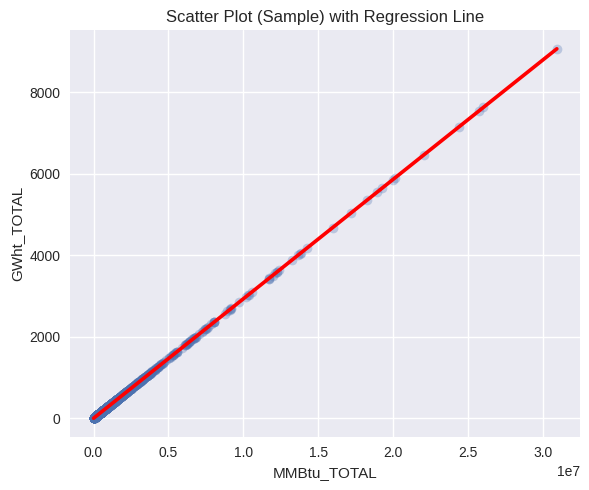

In [ ]:
df_sample = df.sample(n=min(5000, len(df)), random_state=42)

plt.figure(figsize=(6, 5))
sns.regplot(
    x="MMBtu_TOTAL",
    y="GWht_TOTAL",
    data=df_sample,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Scatter Plot (Sample) with Regression Line")
plt.tight_layout()
plt.show()

# Question: How did we perform the encoding (feature engineering) of the categorical variables?

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df[["MMBtu_TOTAL", "FUEL_TYPE", "GROUPING"]].copy()

numeric_features = ["MMBtu_TOTAL"]
categorical_features = ["FUEL_TYPE", "GROUPING"]

numeric_transformer = "passthrough"
categorical_transformer = OneHotEncoder(handle_unknown="ignore", max_categories=10)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Fit the encoder and transform X
X_encoded = preprocess.fit_transform(X)

# Build a DataFrame of encoded features (for visualization only)
ohe = preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(cat_feature_names)

encoded_df = pd.DataFrame(X_encoded.toarray() if hasattr(X_encoded, "toarray") else X_encoded,
                          columns=all_feature_names)

encoded_df.head()

,MMBtu_TOTAL,FUEL_TYPE_Bituminous,FUEL_TYPE_Distillate Fuel Oil No. 2,FUEL_TYPE_Fuel Gas,FUEL_TYPE_Landfill Gas,FUEL_TYPE_Natural Gas (Weighted U.S. Average),FUEL_TYPE_Propane,FUEL_TYPE_Propane Gas,FUEL_TYPE_Residual Fuel Oil No. 6,FUEL_TYPE_Wood and Wood Residuals (dry basis),...,GROUPING_Administrative and Support and Waste Management and Remediation Services,GROUPING_Chemical Manufacturing,GROUPING_Food Manufacturing,GROUPING_Mining and Extraction,GROUPING_Nonmetallic Mineral Products,GROUPING_Paper Manufacturing,GROUPING_Petroleum and Coal Products,GROUPING_Transportation and Warehousing,GROUPING_Utilities,GROUPING_infrequent_sklearn
0,1095.021152,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1488.773186,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1488.773186,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2803.449398,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,847.512559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


/tmp/ipython-input-2575837233.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=src_counts.index, y=src_counts.values, palette="coolwarm")


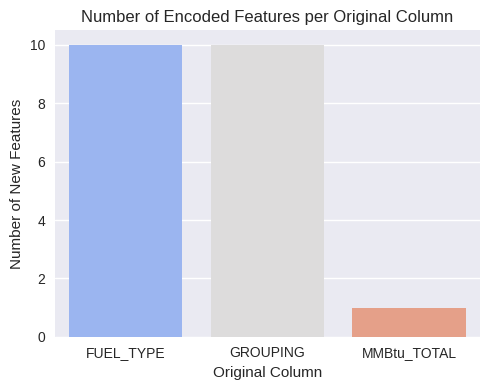

,count
FUEL_TYPE,10
GROUPING,10
MMBtu_TOTAL,1


In [ ]:
feature_source = []
for name in all_feature_names:
    if name.startswith("FUEL_TYPE_"):
        feature_source.append("FUEL_TYPE")
    elif name.startswith("GROUPING_"):
        feature_source.append("GROUPING")
    else:
        feature_source.append("MMBtu_TOTAL")

src_counts = pd.Series(feature_source).value_counts()

plt.figure(figsize=(5, 4))
sns.barplot(x=src_counts.index, y=src_counts.values, palette="coolwarm")
plt.title("Number of Encoded Features per Original Column")
plt.xlabel("Original Column")
plt.ylabel("Number of New Features")
plt.tight_layout()
plt.show()

display(src_counts)

#How does the model perform in predicting GWht_TOTAL?
#Can we use residuals to identify anomalous outcomes?

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

y = df["GWht_TOTAL"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2:", r2)
print("RMSE:", rmse)

residuals = y_test - y_pred

results_df = pd.DataFrame({
    "MMBtu_TOTAL": X_test["MMBtu_TOTAL"],
    "FUEL_TYPE": X_test["FUEL_TYPE"],
    "GROUPING": X_test["GROUPING"],
    "GWht_TOTAL_actual": y_test,
    "GWht_TOTAL_pred": y_pred,
    "residual": residuals
})

results_df.head()

R2: 1.0
RMSE: 9.068422817208108e-08


,MMBtu_TOTAL,FUEL_TYPE,GROUPING,GWht_TOTAL_actual,GWht_TOTAL_pred,residual
451,963.228116,Propane Gas,Administrative and Support and Waste Managemen...,0.282296,0.282296,1.280797e-09
17160,374638.145500,Natural Gas (Weighted U.S. Average),Nonmetallic Mineral Products,109.796298,109.796298,-4.250934e-08
4269,4261.967584,Natural Gas (Weighted U.S. Average),Mining and Extraction,1.249067,1.249067,7.301995e-10
16582,755.813954,Distillate Fuel Oil No. 2,Educational Services,0.221509,0.221509,1.193847e-09
16324,2973.991708,Natural Gas (Weighted U.S. Average),Educational Services,0.871596,0.871596,2.521549e-10


# What are the points where the prediction (residual) error is large?

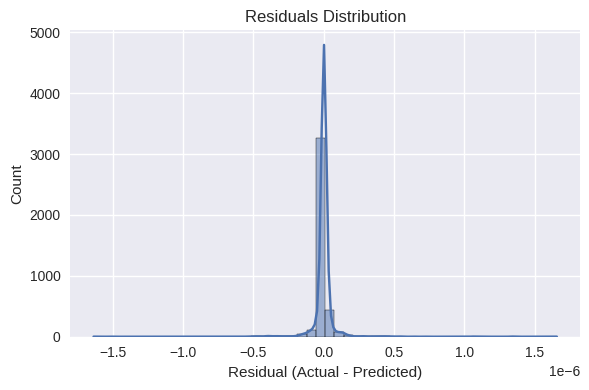

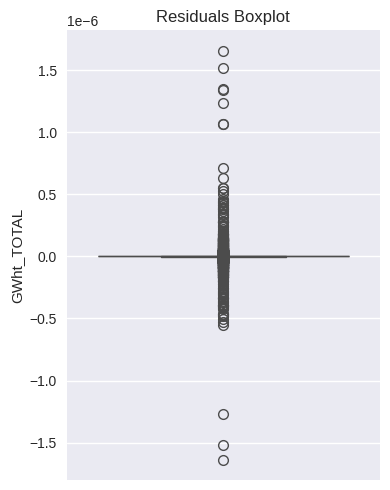

,MMBtu_TOTAL,FUEL_TYPE,GROUPING,GWht_TOTAL_actual,GWht_TOTAL_pred,residual,abs_residual
9938,19969311.86,Fuel Gas,Petroleum and Coal Products,5852.464704,5852.464702,0.000002,0.000002
17900,25707647.95,Natural Gas (Weighted U.S. Average),Primary Metals,7534.215662,7534.215664,-0.000002,0.000002
4170,13771907.27,Natural Gas (Weighted U.S. Average),Mining and Extraction,4036.173193,4036.173191,0.000002,0.000002
3800,13656980.78,Natural Gas (Weighted U.S. Average),Mining and Extraction,4002.491347,4002.491349,-0.000002,0.000002
14187,12117835.59,Fuel Gas,Chemical Manufacturing,3551.409562,3551.409561,0.000001,0.000001
4667,11688901.24,Natural Gas (Weighted U.S. Average),Mining and Extraction,3425.700516,3425.700515,0.000001,0.000001
6350,14237891.07,Natural Gas (Weighted U.S. Average),Utilities,4172.740427,4172.740428,-0.000001,0.000001
12931,18930697.32,Natural Gas (Weighted U.S. Average),Chemical Manufacturing,5548.074899,5548.074898,0.000001,0.000001
14511,11732825.10,Natural Gas (Weighted U.S. Average),Chemical Manufacturing,3438.573410,3438.573409,0.000001,0.000001
14578,13244932.15,Natural Gas (Weighted U.S. Average),Chemical Manufacturing,3881.731051,3881.731050,0.000001,0.000001


In [29]:
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 5))
sns.boxplot(y=residuals)
plt.title("Residuals Boxplot")
plt.tight_layout()
plt.show()

# Show top 10 absolute residuals (largest errors)
results_df["abs_residual"] = results_df["residual"].abs()
anomalies = results_df.sort_values("abs_residual", ascending=False).head(10)
display(anomalies)

#What does the efficiency distribution look like in general? Are there strong outliers?

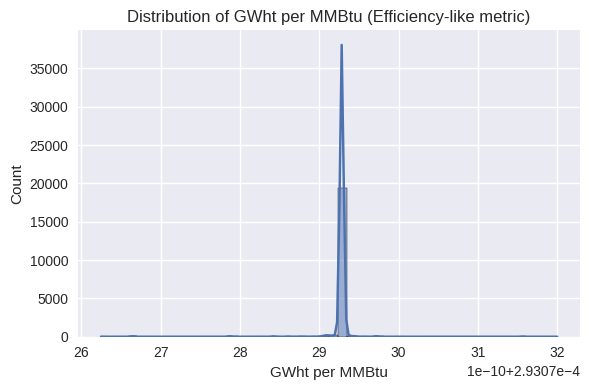

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
df_eff = df.copy()
df_eff["EFF_GWht_per_MMBtu"] = df_eff["GWht_TOTAL"] / df_eff["MMBtu_TOTAL"]
df_eff.replace([np.inf, -np.inf], np.nan, inplace=True)
df_eff = df_eff.dropna(subset=["EFF_GWht_per_MMBtu"])
sns.histplot(df_eff["EFF_GWht_per_MMBtu"], bins=50, kde=True)
plt.title("Distribution of GWht per MMBtu (Efficiency-like metric)")
plt.xlabel("GWht per MMBtu")
plt.tight_layout()
plt.show()

# Are there differences in the types of fuel?

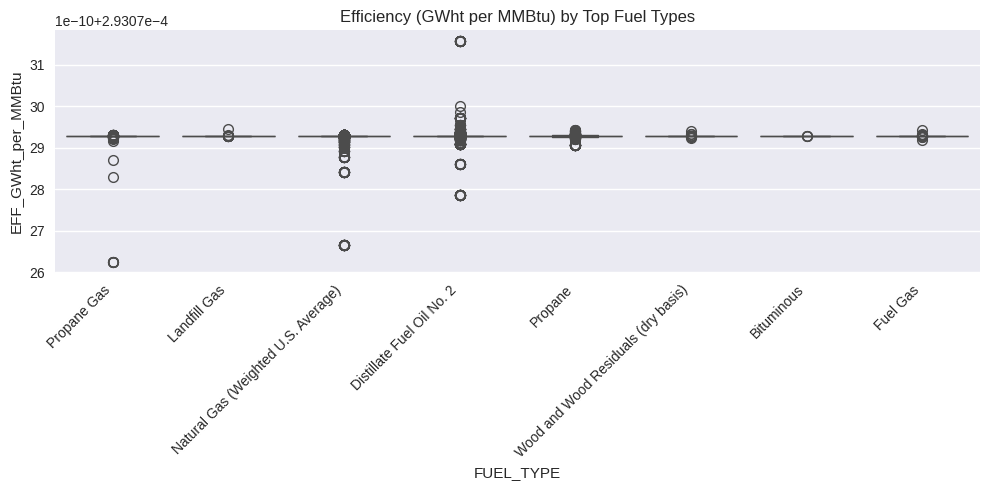

In [27]:
top_fuels = df_eff["FUEL_TYPE"].value_counts().head(8).index
df_eff_top_fuels = df_eff[df_eff["FUEL_TYPE"].isin(top_fuels)]

plt.figure(figsize=(10,5))
sns.boxplot(data=df_eff_top_fuels, x="FUEL_TYPE", y="EFF_GWht_per_MMBtu")
plt.xticks(rotation=45, ha="right")
plt.title("Efficiency (GWht per MMBtu) by Top Fuel Types")
plt.tight_layout()
plt.show()

# Does the unit type affect efficiency?

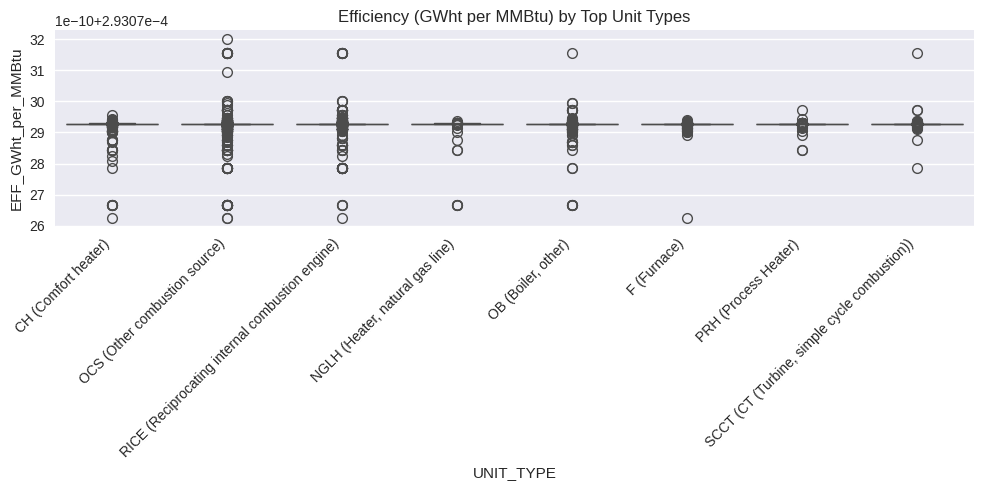

In [28]:
top_units = df_eff["UNIT_TYPE"].value_counts().head(8).index
df_eff_top_units = df_eff[df_eff["UNIT_TYPE"].isin(top_units)]

plt.figure(figsize=(10,5))
sns.boxplot(data=df_eff_top_units, x="UNIT_TYPE", y="EFF_GWht_per_MMBtu")
plt.xticks(rotation=45, ha="right")
plt.title("Efficiency (GWht per MMBtu) by Top Unit Types")
plt.tight_layout()
plt.show()

# What is the relationship between industry type (GROUPING) and fuel types used?

# Objective: We will perform a cross-tab analysis and view a heatmap of the most commonly used industries and fuels.

In [ ]:
top_groupings = df["GROUPING"].value_counts().head(8).index
top_fuels = df["FUEL_TYPE"].value_counts().head(8).index

df_cross = df[df["GROUPING"].isin(top_groupings) & df["FUEL_TYPE"].isin(top_fuels)]
ct = pd.crosstab(df_cross["GROUPING"], df_cross["FUEL_TYPE"])
ct

FUEL_TYPE,Bituminous,Distillate Fuel Oil No. 2,Fuel Gas,Landfill Gas,Natural Gas (Weighted U.S. Average),Propane,Propane Gas,Wood and Wood Residuals (dry basis)
GROUPING,,,,,,,,
Administrative and Support and Waste Management and Remediation Services,1,328,10,222,644,235,530,5
Chemical Manufacturing,46,175,298,13,1267,30,2,7
Mining and Extraction,17,343,29,2,2377,47,3,0
Nonmetallic Mineral Products,85,95,0,3,519,36,9,2
Paper Manufacturing,78,110,0,3,554,32,1,169
Petroleum and Coal Products,5,89,1118,0,443,25,8,0
Transportation and Warehousing,1,48,2,0,1806,2,0,0
Utilities,71,1014,7,20,1875,57,8,44
